In [ ]:
import numpy as np
import csv

In [ ]:
def read_mfsys(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    parts = []
    reading_parts = False
    
    for line in lines:
        if line.strip() == '[parts]':
            reading_parts = True
            continue
        if reading_parts and line.strip():
            parts.append(list(map(float, line.split()[:6])))
    
    return np.array(parts)

In [ ]:
def calculate_energy(parts, interaction_range=None, box_size=None):
    n = len(parts)
    energy_matrix = np.zeros((n, n))
    
    # Извлечение координат и магнитных моментов
    xy = parts[:, 1:3]  # Координаты x, y
    m = parts[:, 4:6]   # Магнитные моменты mx, my
    
    for i in range(n):
        # Вектор расстояний с учетом граничных условий
        dxy = xy - xy[i]
        
        # Применение периодических граничных условий
        if box_size is not None:
            dxy = dxy - np.round(dxy / box_size) * box_size
        
        # Расстояние между частицами
        r = np.sqrt((dxy**2).sum(axis=1))
        r[r == 0] = 1e307  # Исключаем взаимодействие частицы с собой
        
        # Расчет энергии по формуле
        A = np.dot(m, m[i]) / (r**3)
        B = (dxy * m[i]).sum(axis=1) * (dxy * m).sum(axis=1) / (r**5)
        E_i = A - 3 * B
        
        # Учет диапазона взаимодействия
        if interaction_range is not None:
            E_i[r > interaction_range] = 0
        
        energy_matrix[i] = E_i
    
    return energy_matrix


def save_to_csv(matrix, file_path, interaction_range, box_size):

    with open(file_path, 'w', newline='') as file:
        writer = csv.writer(file, delimiter=';')
        
        # Запись комментариев с параметрами
        writer.writerow([f"# Граничные условия: {'периодические' if box_size is not None else 'открытые'}"])
        writer.writerow([f"# Тип взаимодействия: {'ближайшие соседи' if interaction_range is not None else 'все-со-всеми'}"])
        if interaction_range is not None:
            writer.writerow([f"# Диапазон взаимодействия: {interaction_range}"])
        
       # Запись матрицы энергии
        for row in matrix:
            if interaction_range is not None:
                row = [f"{val:.6f}" if val != 0 else "" for val in row]
            else:
                row = [f"{val:.6f}" for val in row]
            writer.writerow(row)

In [ ]:
mfsys_file = 'allepo_N48.mfsys'
csv_file = 'al48_all.csv'
interaction_range = None # значение для взаимодействия с ближайшими соседями
box_size = None  # размера системы для периодических граничных условий
    
parts = read_mfsys(mfsys_file)
energy_matrix = calculate_energy(parts, interaction_range, box_size)
save_to_csv(energy_matrix, csv_file, interaction_range, box_size)

**# Визуализация результатов**

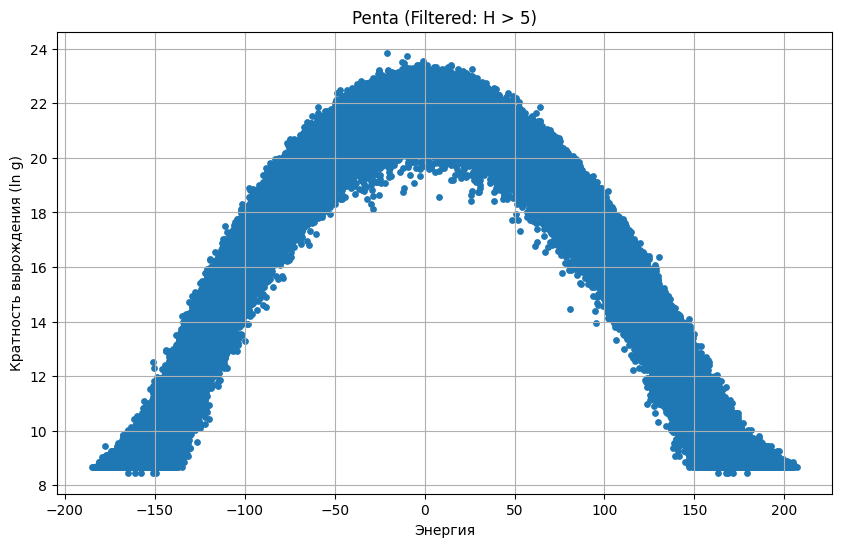

In [ ]:
import csv
import matplotlib.pyplot as plt

# --- НАСТРОЙКИ ---
file_path = 'WL_output_al48_all_25.dat'  # путь к файлу
MIN_VISITS = 5  # <-- ФИЛЬТР: Если бин посетили менее 50 раз, мы его не рисуем
# -----------------

x_values = []
y_values = []

# Определяем разделитель
if file_path.endswith('.csv'):
    delimiter = ';'
elif file_path.endswith('.dat'):
    delimiter = None 
else:
    raise ValueError("Unsupported file format. Please use .csv or .dat")

with open(file_path, 'r', encoding='utf-8') as datafile:
    # Обработка DAT файлов
    if file_path.endswith('.dat'):
        for line in datafile:
            line = line.strip()
            # Пропускаем пустые строки и комментарии
            if line and not line.startswith('#'):
                parts = line.split()
                # Нам нужно минимум 4 колонки: E, log(g), log(g)/n, H(E)
                if len(parts) >= 4:
                    visits = float(parts[3]) # Читаем 4-ю колонку (H)
                    
                    # ГЛАВНАЯ ПРОВЕРКА
                    if visits > MIN_VISITS:
                        x_values.append(float(parts[0]))
                        y_values.append(float(parts[1]))
                        
    # Обработка CSV (если вдруг используете его)
    else:
        csv_reader = csv.reader(datafile, delimiter=delimiter)
        for row in csv_reader:
            if row and not row[0].startswith('#'):
                if len(row) >= 4:
                    visits = float(row[3])
                    if visits > MIN_VISITS:
                        x_values.append(float(row[0]))
                        y_values.append(float(row[1]))

# Построение графика
plt.figure(figsize=(10, 6))

# s=10 уменьшает размер точек, чтобы график был аккуратнее
plt.scatter(x_values, y_values, s=15, marker='o') 

plt.xlabel('Энергия')
plt.ylabel('Кратность вырождения (ln g)')
plt.title(f'Penta (Filtered: H > {MIN_VISITS})')
plt.grid(True)
plt.savefig("penta48_cleaned.png", bbox_inches='tight')
plt.show()


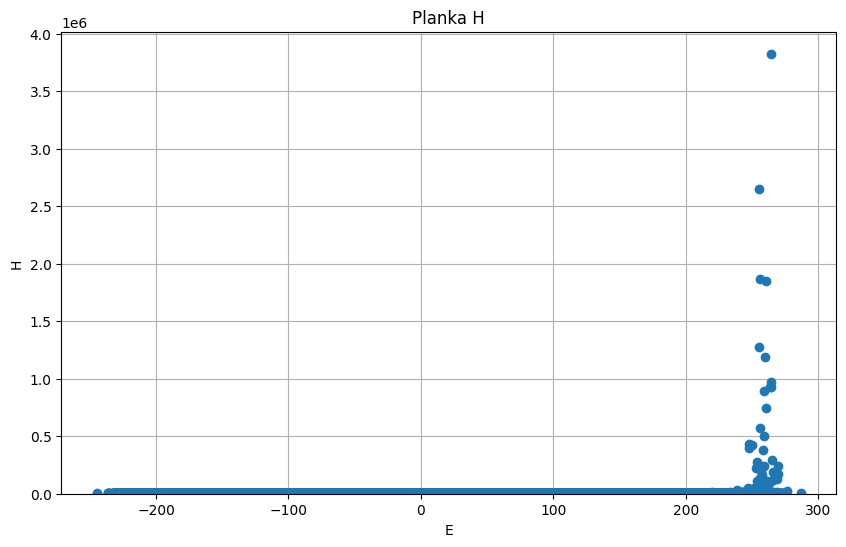

In [3]:
import csv
import matplotlib.pyplot as plt

file_path = 'WL_output_al48_all_2.dat'  # путь к файлу
x_values = []
y_values = []

# Определяем разделитель в зависимости от расширения файла
if file_path.endswith('.csv'):
    delimiter = ';'
elif file_path.endswith('.dat'):
    delimiter = None  # Для DAT файлов попробуем пробельный разделитель
else:
    raise ValueError("Unsupported file format. Please use .csv or .dat")

with open(file_path, 'r', encoding='utf-8') as datafile:
    # Для DAT файлов пробуем сначала split(), потом указанный разделитель
    if file_path.endswith('.dat'):
        for line in datafile:
            line = line.strip()
            if line and not line.startswith('#'):  # Пропускаем пустые строки и комментарии
                parts = line.split()  # Разделяем по пробелам
                if len(parts) >= 2:
                    x_values.append(float(parts[0]))
                    y_values.append(float(parts[3]))
    else:
        # Обработка CSV
        csv_reader = csv.reader(datafile, delimiter=delimiter)
        for row in csv_reader:
            if row:  # Проверяем, что строка не пустая
                x_values.append(float(row[0]))
                y_values.append(float(row[3]))

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, marker='o', linestyle=' ')
plt.xlabel('E')
plt.ylabel('H')
plt.title('Planka H')
plt.ylim(0, max(y_values) * 1.05)
# plt.xscale('log')
plt.grid(True)
plt.savefig("penta_H.png", bbox_inches='tight')
plt.show()